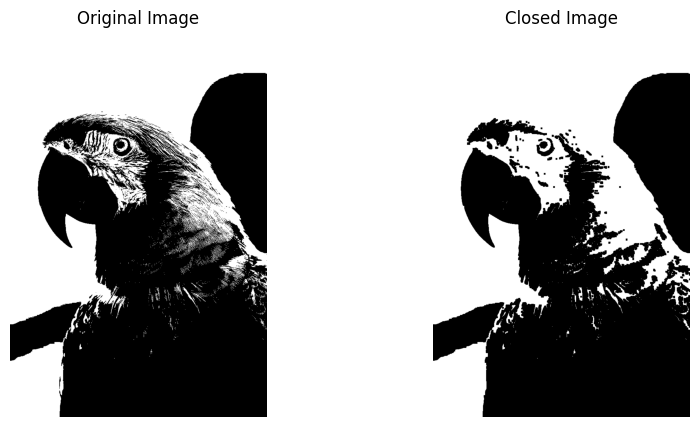

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the parrot image
# Ensure the path '/content/parrot image.avif' is correct
image_path = '/content/parrot image.avif'
color_image = cv2.imread(image_path)

if color_image is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Convert the image to grayscale, as morphological operations usually work on single-channel images
    image = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)

    # Apply a threshold to make it a binary image (optional, but good for clear closing effects)
    # You might need to adjust the threshold value based on the image content
    _, image = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    # Define a kernel (structuring element)
    # A common choice is a rectangular kernel
    kernel_size = 5
    kernel = np.ones((kernel_size, kernel_size), np.uint8)

    # Apply the Closing operation
    # Closing is defined as a Dilation followed by an Erosion.
    # It is useful for closing small holes inside foreground objects and smoothing their boundaries.
    closed_image = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

    # Display the original and closed images
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(closed_image, cmap='gray')
    plt.title('Closed Image')
    plt.axis('off')

    plt.show()